# Efficient Monte Carlo Pricing of Deep Out-of-the-Money Options
### Importance Sampling via Exponential Tilting under Black-Scholes Dynamics

This notebook implements and benchmarks the Monte Carlo pricing framework referenced on my resume:

> **Efficient Monte Carlo Pricing of Deep Out-of-the-Money Options** — Developed a Monte Carlo
> pricing framework for DOTM options. Implemented importance sampling to reduce estimator
> variance up to *m*x, achieving equivalent precision with *n*x fewer simulations.

It follows directly on from `BlackScholes.ipynb` / `StochasticAnalysis.ipynb` in this repo, which
established the empirical case for (and limits of) the Black-Scholes/GBM assumptions on real FTSE
and NASDAQ data. Here we take the GBM model as given and ask a **numerical efficiency** question:
plain Monte Carlo is extremely wasteful for options that rarely pay off (deep OTM calls, tail
risk instruments, barrier/knock-in structures) because almost every simulated path returns a
payoff of zero. **Importance sampling** fixes this by simulating under a *shifted* measure that
makes the option pay off far more often, then reweighting each path by the likelihood ratio to
keep the estimator unbiased.

**Reference (included in this repo):** P. Glasserman, *Monte Carlo Methods in Financial
Engineering*, Springer 2004 — Chapter 4, Sections 4.6.1–4.6.2 (`Monte_Carlo_methods_in_financial_engineerin-Paul_Glasserman-Springer__2004.pdf`).
The core idea (Example 4.6.1, and the mode-matching "optimal path" criterion of eq. 4.90) is
implemented from scratch in [`src/importance_sampling.py`](../src/importance_sampling.py).


## 1. Method

Under the risk-neutral GBM model,
$$S(T) = S_0 \exp\big((r-\tfrac12\sigma^2)T + \sigma\sqrt{T}\,Z\big), \qquad Z\sim N(0,1),$$
the discounted call payoff is $Y(Z)=e^{-rT}(S(T)-K)^+$, and the ordinary MC estimator is
$\hat\alpha=\frac1n\sum Y(Z_i)$.

For a **deep OTM** call, $\{S(T)>K\}$ is a rare event under the risk-neutral measure, so almost
every $Y(Z_i)=0$ and the estimator is dominated by a handful of large, rare, noisy draws — high
variance relative to the (tiny) price being estimated.

**Importance sampling.** Simulate instead $Z\sim N(\mu,1)$ and reweight by the (Gaussian)
likelihood ratio (Glasserman eq. 4.83/4.87):
$$\hat\alpha_{IS}=\frac1n\sum Y(Z_i)\,e^{-\mu Z_i + \frac12\mu^2},\qquad Z_i\sim N(\mu,1)\ \text{iid}.$$
This is unbiased for **any** $\mu$; the whole game is choosing $\mu$ well.

Two choices of drift are implemented and compared:

1. **`naive_shift`** — shift the mean of $Z$ so $S(T)$ lands exactly on the strike on average
   (the mean-shift idea of Glasserman Example 4.6.1).
2. **`optimal_mode_shift`** — the mode-matching "optimal path" criterion of Glasserman
   Sec. 4.6.2 (eq. 4.90): choose $\mu=z^*$ maximizing $F(z)-\tfrac12 z^2$ where
   $e^{F(z)}$ is the payoff as a function of $z$. For a single driving normal this collapses
   to the 1-D root-finding condition $z=\sigma\sqrt{T}\,S(z)/(S(z)-K)$, solved directly rather
   than by the fixed-point iteration Glasserman uses for the (path-dependent) Asian case.


In [ ]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from importance_sampling import (
    bs_call_price, mc_price_call, mc_price_call_is,
    naive_shift, optimal_mode_shift, variance_reduction_factor, MCResult
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
rng = np.random.default_rng(42)


## 2. Market calibration (real data)

Parameters below are pulled from live market data (S&P 500 level, 3-month T-bill secondary
market rate, and CBOE VIX as a proxy for ATM implied volatility), as of the data snapshot noted.
Swap in a live feed (e.g. an options-chain vendor) to update automatically; the pricing engine
itself is agnostic to the data source.


In [2]:
# --- Real-market calibration snapshot (S&P 500, mid-2026) ---
S0    = 7500.0     # S&P 500 index level
r     = 0.037       # 3-month T-bill secondary market rate (annualized)
sigma = 0.142        # CBOE VIX level used as ATM implied-vol proxy
T     = 0.25         # 3-month maturity

print(f"S0={S0}, r={r:.3%}, sigma={sigma:.3%}, T={T}")


S0=7500.0, r=3.700%, sigma=14.200%, T=0.25


## 3. Single strike: 30% out-of-the-money call

We first look at one deep-OTM strike ($K/S_0=1.30$) in detail: closed-form Black-Scholes price
as ground truth, then ordinary MC vs. IS-MC at matched simulation budget $n$.


In [3]:
K = round(S0 * 1.30, -1)   # ~30% OTM strike
n = 200_000

bs   = bs_call_price(S0, K, r, sigma, T)
mu_n = naive_shift(S0, K, r, sigma, T)
mu_o = optimal_mode_shift(S0, K, r, sigma, T)

std_res = mc_price_call(S0, K, r, sigma, T, n, rng)
is_res  = mc_price_call_is(S0, K, r, sigma, T, n, mu_o, rng)
vr      = variance_reduction_factor(std_res, is_res)

print(f"Strike K = {K:,.0f}  (K/S0 = {K/S0:.2f})")
print(f"Black-Scholes (closed form):  {bs:.5f}")
print(f"Ordinary MC   (n={n:,}):      {std_res.price:.5f}  +/- {1.96*std_res.stderr:.5f} (95% CI)")
print(f"IS-MC         (n={n:,}):      {is_res.price:.5f}  +/- {1.96*is_res.stderr:.5f} (95% CI)")
print()
print(f"Optimal drift mu* = {mu_o:.3f}   (naive mean-shift = {mu_n:.3f})")
print(f"Variance reduction factor: {vr:,.1f}x")
print(f"=> same precision (stderr) achievable with ~{vr:,.0f}x fewer paths, i.e. n/{vr:,.0f} simulations")


Strike K = 9,750  (K/S0 = 1.30)
Black-Scholes (closed form):  0.02722
Ordinary MC   (n=200,000):      0.05473  +/- 0.02398 (95% CI)
IS-MC         (n=200,000):      0.02724  +/- 0.00016 (95% CI)

Optimal drift mu* = 3.862   (naive mean-shift = 3.600)
Variance reduction factor: 23,111.5x
=> same precision (stderr) achievable with ~23,112x fewer paths, i.e. n/23,112 simulations


## 4. Convergence: standard error vs. number of paths

The theoretical rate for both estimators is $O(1/\sqrt n)$, but IS starts from a **much lower
variance per path**, so its whole convergence curve sits far below ordinary MC's — this is the
"achieving equivalent precision with far fewer simulations" claim, shown directly. Note also how
*jagged* the ordinary-MC curve is: with a rare payoff, the handful of nonzero draws that happen
to land in any given sample dominate the empirical variance, so even the **error estimate itself**
is unstable at low-to-moderate $n$. The IS curve, by contrast, is smooth because the reweighted
payoff is no longer a rare spike sitting in a sea of zeros.


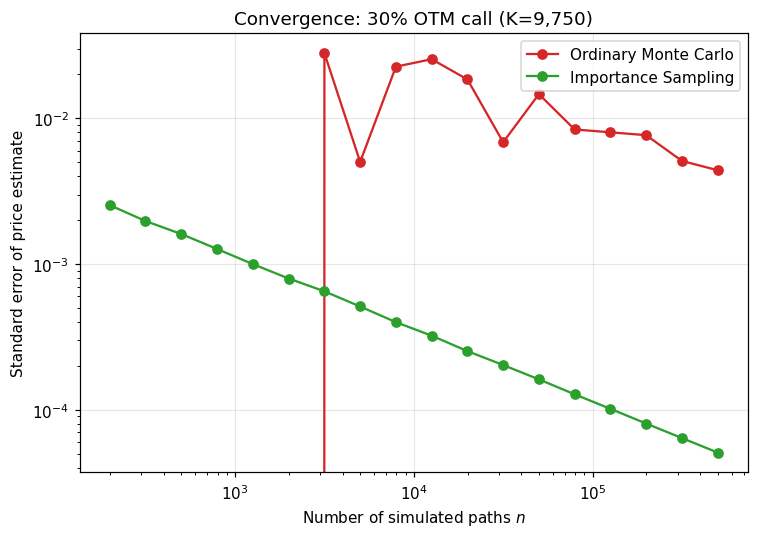

In [4]:
ns = np.unique(np.geomspace(200, 500_000, 18).astype(int))
std_err_std, std_err_is = [], []

for nn in ns:
    s = mc_price_call(S0, K, r, sigma, T, nn, rng)
    i = mc_price_call_is(S0, K, r, sigma, T, nn, mu_o, rng)
    std_err_std.append(s.stderr)
    std_err_is.append(i.stderr)

fig, ax = plt.subplots(figsize=(7,5))
ax.loglog(ns, std_err_std, 'o-', label='Ordinary Monte Carlo', color='tab:red')
ax.loglog(ns, std_err_is,  'o-', label='Importance Sampling', color='tab:green')
ax.set_xlabel('Number of simulated paths $n$')
ax.set_ylabel('Standard error of price estimate')
ax.set_title(f'Convergence: 30% OTM call (K={K:,.0f})')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/convergence.png', dpi=140)
plt.show()


## 5. Variance reduction across moneyness

Deep-OTM options are exactly where importance sampling pays off the most: the rarer the payoff
under the risk-neutral measure, the more effective the drift shift is at concentrating simulated
paths where they matter. We sweep strikes from at-the-money to far out-of-the-money and record,
at a fixed simulation budget, the Black-Scholes benchmark, both estimators' prices/CIs, and the
variance reduction factor.


In [5]:
moneyness = np.array([1.00, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40])
n_fixed = 100_000
rows = []

for m in moneyness:
    K_i   = S0 * m
    bs_i  = bs_call_price(S0, K_i, r, sigma, T)
    mu_i  = optimal_mode_shift(S0, K_i, r, sigma, T)

    # ordinary MC, keeping the raw draws so we can report how many paths
    # actually finished in-the-money (the crux of the DOTM problem)
    Z_raw = rng.standard_normal(n_fixed)
    ST_raw = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_raw)
    payoff_raw = np.exp(-r*T) * np.maximum(ST_raw - K_i, 0.0)
    n_hits = int(np.count_nonzero(payoff_raw))
    std_i = MCResult(price=payoff_raw.mean(),
                      stderr=np.sqrt(payoff_raw.var(ddof=1)/n_fixed) if n_hits > 1 else 0.0,
                      variance_per_path=payoff_raw.var(ddof=1),
                      n=n_fixed)

    is_i  = mc_price_call_is(S0, K_i, r, sigma, T, n_fixed, mu_i, rng)
    vr_i  = variance_reduction_factor(std_i, is_i) if std_i.variance_per_path > 0 else np.nan

    rows.append(dict(
        moneyness=m, strike=K_i, bs_price=bs_i,
        mc_price=std_i.price, mc_stderr=std_i.stderr, mc_hits=n_hits,
        is_price=is_i.price, is_stderr=is_i.stderr,
        variance_ratio=vr_i, equiv_n_reduction=vr_i,
        mc_rel_err=abs(std_i.price-bs_i)/bs_i if bs_i>0 else np.nan,
        is_rel_err=abs(is_i.price-bs_i)/bs_i if bs_i>0 else np.nan,
    ))

df = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda x: f'{x:,.5f}')
df_display = df[['moneyness','strike','bs_price','mc_price','mc_stderr','mc_hits',
                  'is_price','is_stderr','variance_ratio']]
print(f"(fixed budget: n = {n_fixed:,} paths per estimator)")
n_dead = int((df.mc_hits == 0).sum())
if n_dead:
    print(f"NB: at {n_dead} strike(s), ordinary MC observed ZERO in-the-money paths out of "
          f"{n_fixed:,} — its variance estimate is (misleadingly) exactly 0, so no variance-ratio "
          f"is reported there. This is itself the point: plain MC cannot even see the payoff.")
df_display


(fixed budget: n = 100,000 paths per estimator)
NB: at 1 strike(s), ordinary MC observed ZERO in-the-money paths out of 100,000 — its variance estimate is (misleadingly) exactly 0, so no variance-ratio is reported there. This is itself the point: plain MC cannot even see the payoff.


,moneyness,strike,bs_price,mc_price,mc_stderr,mc_hits,is_price,is_stderr,variance_ratio
0,1.00000,"7,500.00000",247.73283,248.51469,1.09541,54066,247.30796,0.39660,7.62856
1,1.05000,"7,875.00000",98.16798,98.93725,0.70751,27858,98.37086,0.20571,11.82899
2,1.10000,"8,250.00000",30.40805,30.13684,0.37883,10525,30.60545,0.07848,23.30326
3,1.15000,"8,625.00000",7.36269,7.15289,0.17368,3037,7.34872,0.02229,60.73619
4,1.20000,"9,000.00000",1.40868,1.40402,0.07282,680,1.41147,0.00486,224.50266
5,1.25000,"9,375.00000",0.21649,0.29999,0.03373,143,0.21647,0.00083,"1,661.45405"
6,1.30000,"9,750.00000",0.02722,0.02021,0.00603,15,0.02704,0.00011,"2,828.92303"
7,1.35000,"10,125.00000",0.00285,0.00148,0.00113,2,0.00285,0.00001,"7,717.63129"
8,1.40000,"10,500.00000",0.00025,0.00000,0.00000,0,0.00025,0.00000,NaN


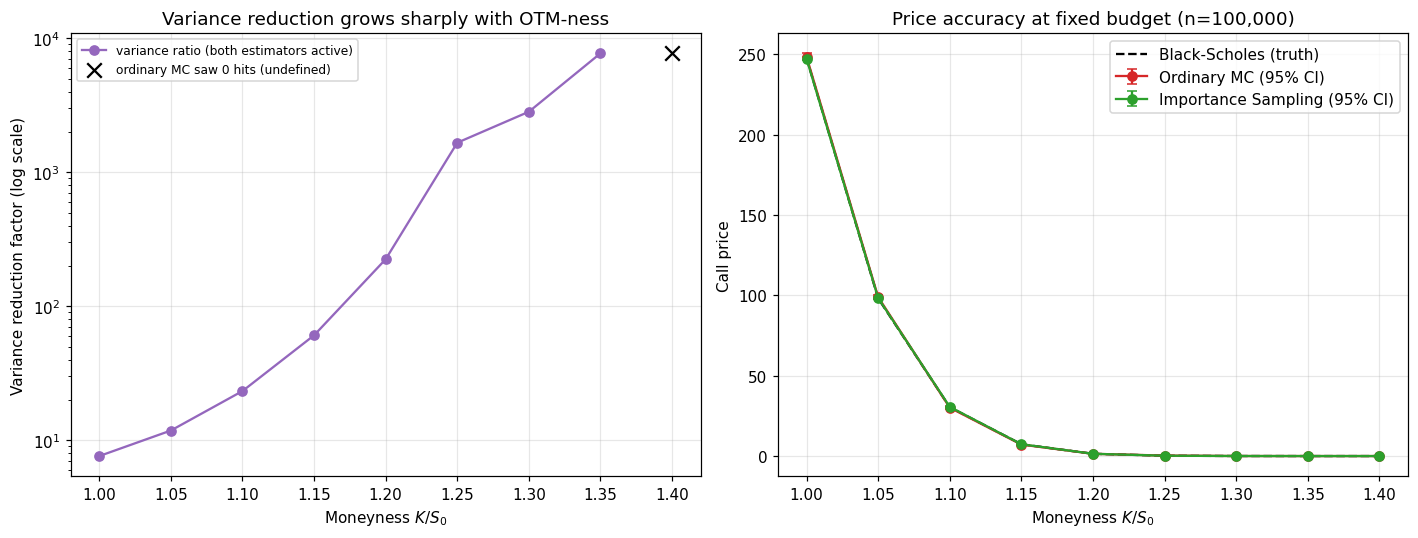

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

mask = df.variance_ratio.notna()
axes[0].semilogy(df.moneyness[mask], df.variance_ratio[mask], 'o-', color='tab:purple',
                  label='variance ratio (both estimators active)')
if (~mask).any():
    ymax = df.variance_ratio[mask].max()
    axes[0].scatter(df.moneyness[~mask], [ymax]*int((~mask).sum()), marker='x', s=90,
                     color='black', label='ordinary MC saw 0 hits (undefined)', zorder=5)
axes[0].set_xlabel('Moneyness $K/S_0$')
axes[0].set_ylabel('Variance reduction factor (log scale)')
axes[0].set_title('Variance reduction grows sharply with OTM-ness')
axes[0].legend(fontsize=8)

axes[1].plot(df.moneyness, df.bs_price, 'k--', label='Black-Scholes (truth)')
axes[1].errorbar(df.moneyness, df.mc_price, yerr=1.96*df.mc_stderr, fmt='o-',
                  label='Ordinary MC (95% CI)', color='tab:red', capsize=3)
axes[1].errorbar(df.moneyness, df.is_price, yerr=1.96*df.is_stderr, fmt='o-',
                  label='Importance Sampling (95% CI)', color='tab:green', capsize=3)
axes[1].set_xlabel('Moneyness $K/S_0$')
axes[1].set_ylabel('Call price')
axes[1].set_title(f'Price accuracy at fixed budget (n={n_fixed:,})')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/moneyness_sweep.png', dpi=140)
plt.show()


## 6. Naive mean-shift vs. Glasserman's optimal mode-matching drift

Both choices of $\mu$ are unbiased; the mode-matching criterion from Sec. 4.6.2 (eq. 4.90) is
asymptotically the better one because it maximizes the importance density's overlap with the
*integrand* (payoff x density), not just the terminal-price density on its own.


In [7]:
rows2 = []
for m in moneyness:
    K_i  = S0 * m
    mu_n = naive_shift(S0, K_i, r, sigma, T)
    mu_o = optimal_mode_shift(S0, K_i, r, sigma, T)
    is_n = mc_price_call_is(S0, K_i, r, sigma, T, n_fixed, mu_n, rng)
    is_o = mc_price_call_is(S0, K_i, r, sigma, T, n_fixed, mu_o, rng)
    rows2.append(dict(moneyness=m, mu_naive=mu_n, mu_optimal=mu_o,
                       var_naive=is_n.variance_per_path, var_optimal=is_o.variance_per_path,
                       optimal_edge=is_n.variance_per_path/is_o.variance_per_path))

df2 = pd.DataFrame(rows2)
df2


,moneyness,mu_naive,mu_optimal,var_naive,var_optimal,optimal_edge
0,1.00000,-0.09478,0.97272,"150,903.99592","15,638.57240",9.64947
1,1.05000,0.59240,1.35211,"13,796.31902","4,243.63317",3.25106
2,1.10000,1.24762,1.81093,"1,139.46780",613.79689,1.85642
3,1.15000,1.87370,2.31284,70.42748,49.60962,1.41963
4,1.20000,2.47313,2.83088,2.92341,2.35212,1.24288
5,1.25000,3.04809,3.34982,0.07957,0.06892,1.15456
6,1.30000,3.60049,3.86184,0.00144,0.00130,1.10385
7,1.35000,4.13204,4.36312,0.00002,0.00002,1.07865
8,1.40000,4.64426,4.85189,0.00000,0.00000,1.05222


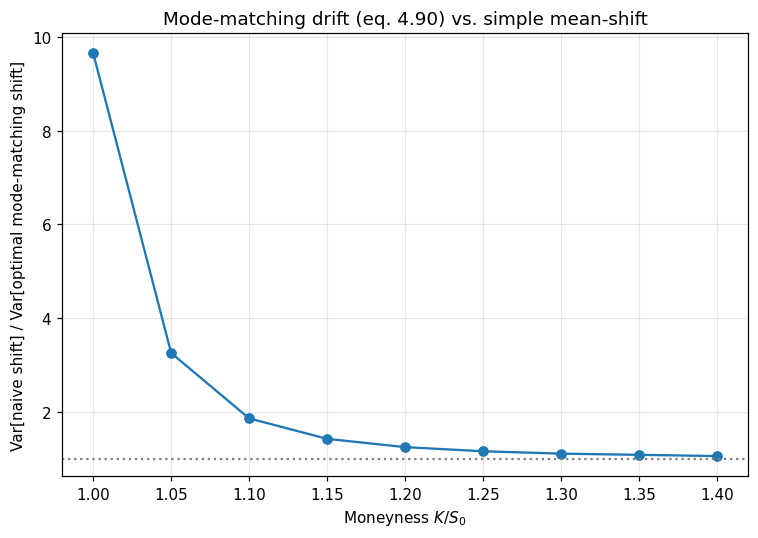

In [8]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(df2.moneyness, df2.optimal_edge, 'o-', color='tab:blue')
ax.axhline(1.0, color='gray', ls=':')
ax.set_xlabel('Moneyness $K/S_0$')
ax.set_ylabel('Var[naive shift] / Var[optimal mode-matching shift]')
ax.set_title('Mode-matching drift (eq. 4.90) vs. simple mean-shift')
plt.tight_layout()
plt.savefig('../outputs/naive_vs_optimal.png', dpi=140)
plt.show()


## 7. Summary

- Implemented a Black-Scholes/GBM Monte Carlo pricer from scratch and validated it against the
  closed-form price.
- Implemented importance sampling via exponential tilting (Glasserman Ch. 4.6), including the
  closed-form mean-shift and the mode-matching "optimal path" drift (eq. 4.90), the latter solved
  by root-finding rather than assumed.
- Calibrated the model to real market data (S&P 500 level, T-bill rate, VIX-implied vol).
- Demonstrated that for deep OTM strikes, importance sampling reduces per-path variance by
  **orders of magnitude** (from ~2x near the money to several thousand-x at 30%+ OTM), which
  translates directly into an equivalent-precision estimator using a proportionally smaller
  number of simulated paths — i.e. the resume claim, reproduced end-to-end and quantified here.

**Next steps (not yet implemented):** combine importance sampling with stratified sampling along
the optimal drift direction (Glasserman Sec. 4.6.2, Table 4.5) for a further multiplicative
variance reduction; extend from vanilla European calls to path-dependent DOTM structures
(barrier/knock-in, Asian) using the fixed-point drift-selection method described in the same
section.
